# DESI KP/Y3 validation with `desi-clustering-cosmo`

This notebook checks that the simple/background Cobaya runs produced by the new `desi-clustering-cosmo` pipeline reproduce the corresponding DESI KP/Y3 official-pipeline results.

The comparisons use the completed `desi-clustering-cosmo` run `uendert-cosmo-dev-mcmc-v2` and overlay it against archived DESI KP/Y3 official Cobaya chains where a close match exists. For DESY5-Dovekie, the BAO+SN comparison must use the archived `DESI_BAO_DESY5-Dovekie` directory; the similarly named `DESY5-Dovekie` directory is SN-only.


In [1]:
from pathlib import Path
from collections import OrderedDict
import sys
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from getdist import loadMCSamples, plots
%matplotlib inline


In [2]:
# Reuse the KP/Y3 plotting style if the companion repo is available.
Y3_KP_SCRIPTS = Path("/global/homes/u/uendert/repos/desi/desi-y3-kp-combined-tracer/scripts")
if Y3_KP_SCRIPTS.exists():
    sys.path.insert(1, str(Y3_KP_SCRIPTS))

try:
    from desi_y3_plotting import KP7StylePaper
    style = KP7StylePaper()
except Exception as exc:
    print(f"Falling back to plain GetDist style: {exc}")
    style = None

getdist_2D_width_inch = 6
getdist_2D_ratio = 1 / 1.2
OUTDIR = Path("plots/simple_chain_comparison")
OUTDIR.mkdir(parents=True, exist_ok=True)

DESI_CLUSTERING_LABEL = "desi-clustering-cosmo"
OFFICIAL_PIPELINE_LABEL = "DESI KP/Y3 official"


## Paths and case definitions

`DESI_CLUSTERING_ROOT` is the output root for the successful `desi-clustering-cosmo` desipipe/background run. Official DESI KP/Y3 comparison chains are mixed because not every simple compression exists in the final v1p2 `run1/base` directory:

- most archived KP/Y3 comparisons use `bao_v1p2/bao/cobaya/camb/run1/base`;
- theta-only and `R,l_A` compressed chains are available in the older `bao_v1p1` root;
- the Dovekie BAO+SN comparison uses Cristhian's archived official `desi_dr2_updated/base/DESI_BAO_DESY5-Dovekie` chain. The sibling `desi_dr2_updated/base/DESY5-Dovekie` chain is SN-only and is not the right reference for `bao-sn-desdovekie`;
- `bao-bbn-fixed-nnu` is the apples-to-apples fixed-`N_eff` BBN comparison against the official KP/Y3 `base` BBN chain.

The varied-`N_eff` `bao-bbn` stress test is intentionally excluded from these validation plots because it is not an apples-to-apples official KP/Y3 `base` comparison.


In [3]:
DESI_CLUSTERING_ROOT = Path("/pscratch/sd/u/uendert/desi-clustering-cosmo-dev/cobaya/camb/uendert-cosmo-dev-mcmc-v2/base")
OFFICIAL_V1P2_ROOT = Path("/global/cfs/cdirs/desicollab/science/cpe/y3_bao_cosmo/bao_v1p2/bao/cobaya/camb/run1/base")
OFFICIAL_V1P1_ROOT = Path("/global/cfs/cdirs/desicollab/science/cpe/y3_bao_cosmo/bao_v1p1/bao/cobaya/camb/run1/base")
OFFICIAL_DR2_UPDATED_ROOT = Path("/global/cfs/cdirs/desicollab/science/cpe/y3_bao_cosmo/bao_v1p2/bao/cobaya/camb/desi_dr2_updated/base")
# Note: OFFICIAL_DR2_UPDATED_ROOT / "DESY5-Dovekie" is SN-only.
# For BAO+SN Dovekie, use "DESI_BAO_DESY5-Dovekie".

CASES = OrderedDict({
    "desi-bao-all": {
        "label": "BAO",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "desi-bao-all",
        "official_dir": OFFICIAL_V1P2_ROOT / "desi-bao-all",
        "official_note": "official KP/Y3 v1p2 run1/base",
    },
    "bao-sn-desdovekie": {
        "label": "BAO + DESY5-Dovekie",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-sn-desdovekie",
        "official_dir": OFFICIAL_DR2_UPDATED_ROOT / "DESI_BAO_DESY5-Dovekie",
        "official_note": "Cristhian archived official BAO+SN Dovekie chain; sibling DESY5-Dovekie is SN-only; this chain uses bao.desi_dr2_updated",
    },
    "bao-bbn-fixed-nnu": {
        "label": r"BAO + BBN (fixed $N_\mathrm{eff}$)",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-bbn-fixed-nnu",
        "official_dir": OFFICIAL_V1P2_ROOT / "desi-bao-all_schoneberg2024-bbn-fixed-nnu",
        "official_note": "apples-to-apples fixed N_eff official KP/Y3 v1p2 run1/base",
    },
    "bao-cmb-compressed-theta": {
        "label": r"BAO + $\theta_*$",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-cmb-compressed-theta",
        "official_dir": OFFICIAL_V1P1_ROOT / "desi-bao-all_CMB-compressed-theta",
        "official_note": "KP/Y3 v1p1 fallback; not exact v1p2 match",
    },
    "bao-cmb-compressed-theta-ombh2": {
        "label": r"BAO + $\theta_* + \omega_b$",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-cmb-compressed-theta-ombh2",
        "official_dir": OFFICIAL_V1P2_ROOT / "desi-bao-all_CMB-compressed-theta-ombh2",
        "official_note": "official KP/Y3 v1p2 run1/base",
    },
    "bao-cmb-compressed-theta-ombh2-ombch2": {
        "label": r"BAO + $\theta_* + \omega_b + \omega_{bc}$",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-cmb-compressed-theta-ombh2-ombch2",
        "official_dir": OFFICIAL_V1P2_ROOT / "desi-bao-all_CMB-compressed-theta-ombh2-ombch2",
        "official_note": "official KP/Y3 v1p2 run1/base",
    },
    "bao-cmb-compressed-r-la": {
        "label": r"BAO + $(R,l_A)$",
        "desi_clustering_dir": DESI_CLUSTERING_ROOT / "bao-cmb-compressed-r-la",
        "official_dir": OFFICIAL_V1P1_ROOT / "desi-bao-all_CMB-compressed-R-lA",
        "official_note": "KP/Y3 v1p1 fallback; not exact v1p2 match",
    },
})

TRACER_CASES = OrderedDict({
    "desi-bao-bgs": "BGS",
    "desi-bao-lrg-z1": "LRG z1",
    "desi-bao-lrg-z2": "LRG z2",
    "desi-bao-lrgpluselg": "LRG+ELG",
    "desi-bao-elg": "ELG",
    "desi-bao-qso": "QSO",
    "desi-bao-lya": r"Ly$\alpha$",
    "desi-bao-all": "All",
})


In [4]:
def chain_prefix(case_dir):
    return Path(case_dir) / "chain"

def chain_exists(case_dir):
    case_dir = Path(case_dir)
    return bool(list(case_dir.glob("chain.*.txt")))

def param_names(samples):
    return [p.name for p in samples.getParamNames().names]

def has_param(samples, name):
    return name in param_names(samples)

def add_derived_aliases(samples):
    # Add small derived aliases so both pipelines share plotting params.
    names = param_names(samples)
    p = samples.getParams()
    if "omegam" not in names and "omm" in names:
        samples.addDerived(p.omm, name="omegam", label=r"\Omega_\mathrm{m}")
    if "H0" not in names and {"hrdrag", "rdrag"}.issubset(names):
        samples.addDerived(100.0 * p.hrdrag / p.rdrag, name="H0", label=r"H_0")
    names = param_names(samples); p = samples.getParams()
    if "hrdrag" not in names and {"H0", "rdrag"}.issubset(names):
        samples.addDerived(p.H0 * p.rdrag / 100.0, name="hrdrag", label=r"H_0 r_\mathrm{d}/100")
    names = param_names(samples); p = samples.getParams()
    if "h" not in names and "H0" in names:
        samples.addDerived(p.H0 / 100.0, name="h", label=r"h")
    names = param_names(samples); p = samples.getParams()
    if "omegamh3" not in names and "omm" in names and "H0" in names:
        samples.addDerived(p.omm * (p.H0 / 100.0) ** 3, name="omegamh3", label=r"\Omega_m h^3")
    return samples

def load_chain(case_dir, label=None, ignore_rows=0.3, no_cache=False):
    # Load a Cobaya/GetDist chain from a directory containing chain.N.txt files.
    if not chain_exists(case_dir):
        raise FileNotFoundError(f"No chain.*.txt files found in {case_dir}")
    samples = loadMCSamples(str(chain_prefix(case_dir)), settings={"ignore_rows": ignore_rows}, no_cache=no_cache)
    add_derived_aliases(samples)
    if label is not None:
        samples.label = label
    return samples

def load_cases(cases=CASES, ignore_rows=0.3):
    pipeline, official, rows = OrderedDict(), OrderedDict(), []
    for key, cfg in cases.items():
        pipeline_ok = chain_exists(cfg["desi_clustering_dir"])
        official_ok = chain_exists(cfg["official_dir"])
        rows.append({
            "case": key,
            "label": cfg["label"],
            "desi_clustering_dir": str(cfg["desi_clustering_dir"]),
            "desi_clustering_exists": pipeline_ok,
            "official_kpy3_dir": str(cfg["official_dir"]),
            "official_kpy3_exists": official_ok,
            "official_kpy3_note": cfg["official_note"],
        })
        if pipeline_ok:
            pipeline[key] = load_chain(cfg["desi_clustering_dir"], label=DESI_CLUSTERING_LABEL + ": " + cfg["label"], ignore_rows=ignore_rows)
        if official_ok:
            official_label = cfg.get("official_label", OFFICIAL_PIPELINE_LABEL)
            official[key] = load_chain(cfg["official_dir"], label=official_label + ": " + cfg["label"], ignore_rows=ignore_rows)
    return pipeline, official, pd.DataFrame(rows)


## Load chains


In [5]:
pipeline_samples, official_samples, availability = load_cases(ignore_rows=0.3)
availability


,case,label,desi_clustering_dir,desi_clustering_exists,official_kpy3_dir,official_kpy3_exists,official_kpy3_note
0,desi-bao-all,BAO,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,official KP/Y3 v1p2 run1/base
1,bao-sn-desdovekie,BAO + DESY5-Dovekie,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,Cristhian archived official BAO+SN Dovekie cha...
2,bao-bbn-fixed-nnu,BAO + BBN (fixed $N_\mathrm{eff}$),/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,apples-to-apples fixed N_eff official KP/Y3 v1...
3,bao-cmb-compressed-theta,BAO + $\theta_*$,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,KP/Y3 v1p1 fallback; not exact v1p2 match
4,bao-cmb-compressed-theta-ombh2,BAO + $\theta_* + \omega_b$,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,official KP/Y3 v1p2 run1/base
5,bao-cmb-compressed-theta-ombh2-ombch2,BAO + $\theta_* + \omega_b + \omega_{bc}$,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,official KP/Y3 v1p2 run1/base
6,bao-cmb-compressed-r-la,"BAO + $(R,l_A)$",/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True,KP/Y3 v1p1 fallback; not exact v1p2 match


In [6]:
# Optional: load individual BAO tracer chains from the dev run.
tracer_samples = OrderedDict()
for case, label in TRACER_CASES.items():
    case_dir = DESI_CLUSTERING_ROOT / case
    if chain_exists(case_dir):
        tracer_samples[case] = load_chain(case_dir, label=label, ignore_rows=0.3)
list(tracer_samples)


['desi-bao-bgs',
 'desi-bao-lrg-z1',
 'desi-bao-lrg-z2',
 'desi-bao-lrgpluselg',
 'desi-bao-elg',
 'desi-bao-qso',
 'desi-bao-lya',
 'desi-bao-all']

## Convergence/status table

Cobaya progress files end with columns `N`, `acceptance_rate`, `Rminus1`, and `Rminus1_cl`. These are the numbers the queue stopped at. The simple/core run used `Rminus1_stop = 0.01` and `Rminus1_cl_stop = 0.02`, so values around/below those thresholds are expected.


In [7]:
def read_progress(case_dir):
    path = Path(case_dir) / "chain.progress"
    if not path.exists():
        return {}
    try:
        df = pd.read_csv(path, comment="#", sep=r"\s+", names=["N", "timestamp", "acceptance_rate", "Rminus1", "Rminus1_cl"])
    except Exception:
        return {}
    if df.empty:
        return {}
    last = df.iloc[-1]
    return {"N": last["N"], "acceptance_rate": last["acceptance_rate"], "Rminus1": last["Rminus1"], "Rminus1_cl": last["Rminus1_cl"], "timestamp": last["timestamp"]}

progress_rows = []
for key, cfg in CASES.items():
    progress_rows.append({"case": key, "label": cfg["label"], "source": DESI_CLUSTERING_LABEL, **read_progress(cfg["desi_clustering_dir"])})
    if chain_exists(cfg["official_dir"]):
        progress_rows.append({"case": key, "label": cfg["label"], "source": OFFICIAL_PIPELINE_LABEL, **read_progress(cfg["official_dir"])})
progress = pd.DataFrame(progress_rows)
progress


,case,label,source,N,acceptance_rate,Rminus1,Rminus1_cl,timestamp
0,desi-bao-all,BAO,desi-clustering-cosmo,50172.0,0.756363,0.001020,0.019861,2026-05-28T14:16:42.693449
1,desi-bao-all,BAO,DESI KP/Y3 official,74162.0,0.759953,0.000759,0.019920,2025-02-09T02:35:19.224734
2,bao-sn-desdovekie,BAO + DESY5-Dovekie,desi-clustering-cosmo,15776.0,0.755878,0.000918,0.018717,2026-05-28T09:29:08.877111
3,bao-sn-desdovekie,BAO + DESY5-Dovekie,DESI KP/Y3 official,128345.0,0.753908,0.000439,0.019789,2026-04-25T03:02:12.565647
4,bao-bbn-fixed-nnu,BAO + BBN (fixed $N_\mathrm{eff}$),desi-clustering-cosmo,92976.0,0.369725,0.000443,0.019721,2026-06-16T11:56:34.615675
5,bao-bbn-fixed-nnu,BAO + BBN (fixed $N_\mathrm{eff}$),DESI KP/Y3 official,94590.0,0.371288,0.000493,0.018663,2025-02-09T03:08:00.325574
6,bao-cmb-compressed-theta,BAO + $\theta_*$,desi-clustering-cosmo,135975.0,0.262796,0.001783,0.019460,2026-05-28T10:05:51.219823
7,bao-cmb-compressed-theta,BAO + $\theta_*$,DESI KP/Y3 official,64926.0,0.254101,0.001904,0.017147,2025-01-07T08:16:29.069034
8,bao-cmb-compressed-theta-ombh2,BAO + $\theta_* + \omega_b$,desi-clustering-cosmo,48931.0,0.370883,0.001439,0.018615,2026-05-28T09:41:49.087702
9,bao-cmb-compressed-theta-ombh2,BAO + $\theta_* + \omega_b$,DESI KP/Y3 official,145944.0,0.369156,0.000355,0.019961,2025-02-06T16:32:08.868395


## Parameter summaries


In [8]:
SUMMARY_PARAMS = ["omm", "omegam", "hrdrag", "H0", "ombh2", "omch2", "rdrag", "omegamh3", "chi2"]

def summarize_samples(samples, params=SUMMARY_PARAMS):
    rows = []
    names = set(param_names(samples))
    for par in params:
        if par in names:
            rows.append({"param": par, "mean": samples.mean(par), "std": samples.std(par)})
    return pd.DataFrame(rows)

summary_rows = []
for case, samples in pipeline_samples.items():
    for _, row in summarize_samples(samples).iterrows():
        summary_rows.append({"case": case, "source": DESI_CLUSTERING_LABEL, **row.to_dict()})
for case, samples in official_samples.items():
    for _, row in summarize_samples(samples).iterrows():
        summary_rows.append({"case": case, "source": OFFICIAL_PIPELINE_LABEL, **row.to_dict()})
summary = pd.DataFrame(summary_rows)
summary_pivot = summary.pivot_table(index=["case", "param"], columns="source", values=["mean", "std"])
summary_pivot


mean                        \
source                     DESI KP/Y3 official desi-clustering-cosmo   
case              param                                                
bao-bbn-fixed-nnu H0                 68.539054             68.543790   
                  chi2               13.242589             13.315294   
                  hrdrag            101.522308            101.517435   
                  ombh2               0.022187              0.022185   
                  omch2               0.117007              0.117080   
...                                        ...                   ...   
desi-bao-all      omch2               0.111962              0.112036   
                  omegam              0.297479              0.297641   
                  omegamh3            0.090920              0.090970   
                  omm                 0.297478              0.297641   
                  rdrag             150.739392            150.715476   

                                           std                        
source                     DESI KP/Y3 official desi-clustering-cosmo  
case              param                                               
bao-bbn-fixed-nnu H0                  0.592872              0.599086  
                  chi2                2.415428              2.468707  
                  hrdrag              0.732024              0.737724  
                  ombh2               0.000544              0.000555  
                  omch2               0.004895              0.004908  
...                                        ...                   ...  
desi-bao-all      omch2               0.003901              0.003911  
                  omegam              0.008598              0.008619  
                  omegamh3            0.002628              0.002634  
                  omm                 0.008598              0.008619  
                  rdrag               1.086306              1.096046  

[61 rows x 4 columns]

In [9]:
def comparison_table(pipeline_samples, official_samples, params=SUMMARY_PARAMS):
    rows = []
    for case, pipeline in pipeline_samples.items():
        official = official_samples.get(case)
        if official is None:
            continue
        common = [p for p in params if has_param(pipeline, p) and has_param(official, p)]
        for par in common:
            desi_clustering_mean, desi_clustering_std = pipeline.mean(par), pipeline.std(par)
            official_mean, official_std = official.mean(par), official.std(par)
            sigma = np.sqrt(desi_clustering_std**2 + official_std**2)
            rows.append({"case": case, "param": par, "desi_clustering_mean": desi_clustering_mean, "desi_clustering_std": desi_clustering_std, "official_mean": official_mean, "official_std": official_std, "delta": desi_clustering_mean - official_mean, "delta_over_joint_sigma": (desi_clustering_mean - official_mean) / sigma if sigma > 0 else np.nan})
    return pd.DataFrame(rows)
comparison = comparison_table(pipeline_samples, official_samples)
comparison


,case,param,desi_clustering_mean,desi_clustering_std,official_mean,official_std,delta,delta_over_joint_sigma
0,desi-bao-all,omm,0.297641,0.008619,0.297478,0.008598,1.632187e-04,0.013406
1,desi-bao-all,omegam,0.297641,0.008619,0.297479,0.008598,1.617310e-04,0.013284
2,desi-bao-all,hrdrag,101.521945,0.738297,101.538054,0.731736,-1.610934e-02,-0.015497
3,desi-bao-all,H0,67.360000,0.000002,67.360000,0.000002,3.071840e-08,0.009445
4,desi-bao-all,omch2,0.112036,0.003911,0.111962,0.003901,7.405843e-05,0.013406
...,...,...,...,...,...,...,...,...
56,bao-cmb-compressed-r-la,ombh2,0.019701,0.001602,0.019718,0.001623,-1.689598e-05,-0.007409
57,bao-cmb-compressed-r-la,omch2,0.116187,0.001011,0.116202,0.001015,-1.424511e-05,-0.009942
58,bao-cmb-compressed-r-la,rdrag,151.283043,2.148402,151.259752,2.172384,2.329155e-02,0.007623
59,bao-cmb-compressed-r-la,omegamh3,0.090888,0.003011,0.090921,0.003056,-3.290947e-05,-0.007672


## BAO tracer sanity plot

This reproduces the common KP-style `H_0 r_d`--`Omega_m` BAO view for the `desi-clustering-cosmo` tracer chains only. 

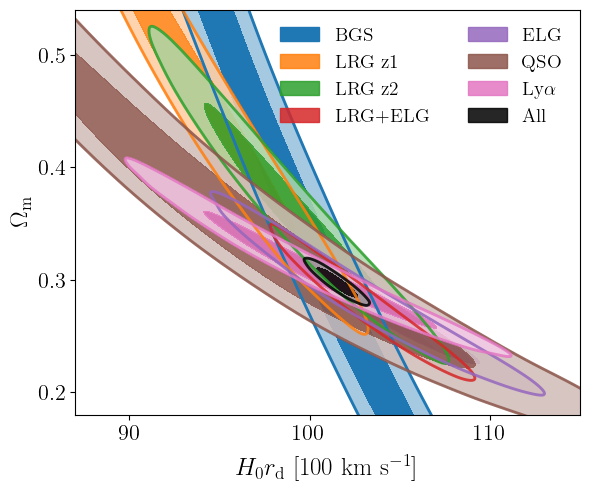

In [10]:
if tracer_samples:
    tracer_order = [case for case in TRACER_CASES if case in tracer_samples]
    samples = [tracer_samples[case] for case in tracer_order]
    labels = [TRACER_CASES[case] for case in tracer_order]
    g = plots.get_single_plotter(width_inch=getdist_2D_width_inch, ratio=getdist_2D_ratio, scaling=True)
    if style is not None:
        g.settings = style.settings
    colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "k"][:len(samples)]
    g.plot_2d(samples, ["hrdrag", "omm"], filled=[True] * len(samples), colors=colors)
    g.add_legend(labels, legend_loc="upper right", legend_ncol=2)
    ax = g.get_axes()
    ax.set_xlabel(r"$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]")
    ax.set_ylabel(r"$\Omega_\mathrm{m}$")
    ax.set_xlim(87, 115)
    ax.set_ylim(0.18, 0.54)
    plt.savefig(OUTDIR / "desi_clustering_bao_tracers_hrdrag_omm.pdf", bbox_inches="tight")


## `desi-clustering-cosmo` vs DESI KP/Y3 official contours

Solid/filled contours are the new `desi-clustering-cosmo` pipeline outputs. Dashed contours are archived DESI KP/Y3 official comparison chains. For Dovekie, the dashed contour is the archived official BAO+SN chain `desi_dr2_updated/base/DESI_BAO_DESY5-Dovekie`; the similarly named `DESY5-Dovekie` chain is SN-only and is not used here. For theta-only and `R,l_A`, the official comparison comes from the v1p1 root because no v1p2 final chain was found in the same official root, so those are not exact v1p2-to-v1p2 archival comparisons.


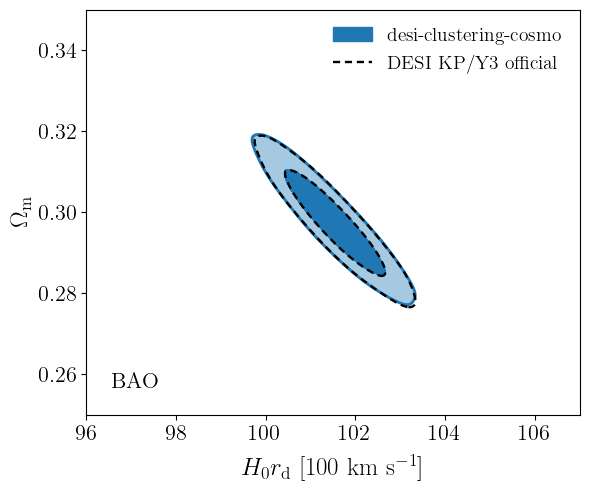

In [11]:
def plot_pipeline_vs_official(case, x="hrdrag", y="omm", limits=None, save=True):
    if case not in pipeline_samples:
        print(f"No desi-clustering-cosmo sample for {case}")
        return None
    roots = [pipeline_samples[case]]
    labels = [DESI_CLUSTERING_LABEL]
    filled = [True]
    colors = ["C0"]
    linestyles = ["-"]
    if case in official_samples:
        roots.append(official_samples[case])
        labels.append(OFFICIAL_PIPELINE_LABEL)
        filled.append(False)
        colors.append("k")
        linestyles.append("--")
    missing = [par for par in [x, y] if not all(has_param(s, par) for s in roots)]
    if missing:
        print(f"Skipping {case}: missing {missing}")
        return None
    g = plots.get_single_plotter(width_inch=getdist_2D_width_inch, ratio=getdist_2D_ratio, scaling=True)
    if style is not None:
        g.settings = style.settings
    g.plot_2d(roots, [x, y], filled=filled, colors=colors, ls=linestyles)
    g.add_legend(labels, legend_loc="upper right")
    g.add_text(CASES[case]["label"], 0.05, 0.08, fontsize=16)
    ax = g.get_axes()
    if x == "hrdrag": ax.set_xlabel(r"$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]")
    if y in {"omm", "omegam"}: ax.set_ylabel(r"$\Omega_\mathrm{m}$")
    if x == "H0": ax.set_xlabel(r"$H_0$ [$\mathrm{km}$ $\mathrm{s}^{-1}$ $\mathrm{Mpc}^{-1}$]")
    if limits:
        if "xlim" in limits: ax.set_xlim(*limits["xlim"])
        if "ylim" in limits: ax.set_ylim(*limits["ylim"])
    if save:
        safe = case.replace("/", "_")
        plt.savefig(OUTDIR / f"{safe}_{x}_{y}_desi_clustering_vs_official_kpy3.pdf", bbox_inches="tight")
    return g

plot_pipeline_vs_official("desi-bao-all", "hrdrag", "omm", limits={"xlim": (96, 107), "ylim": (0.25, 0.35)})


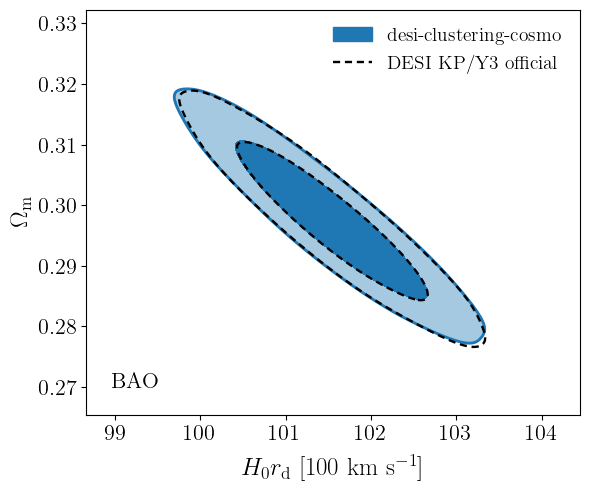

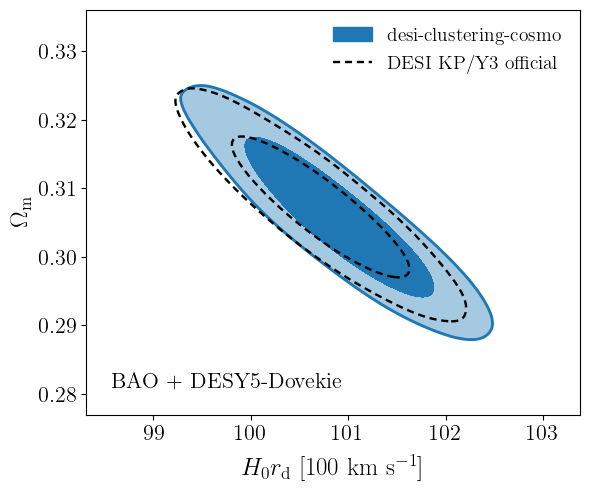

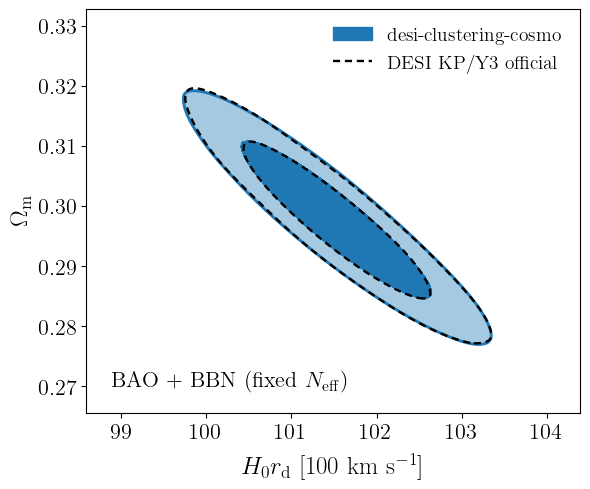

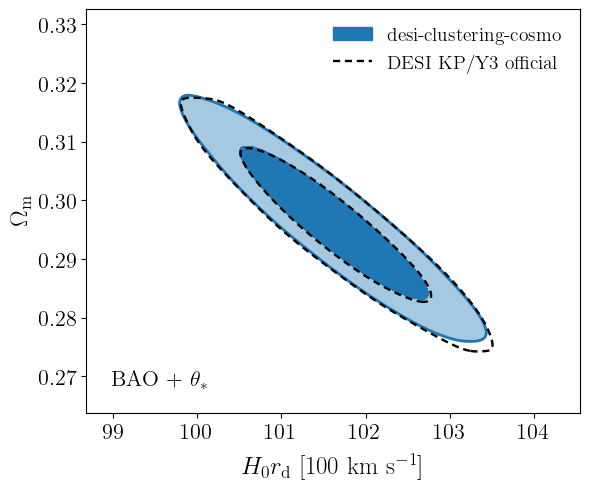

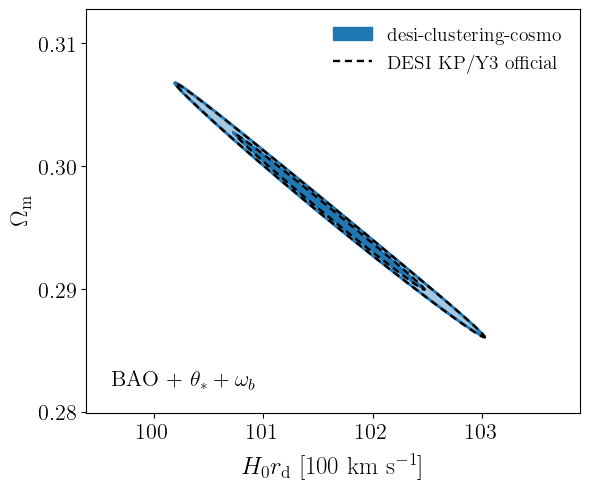

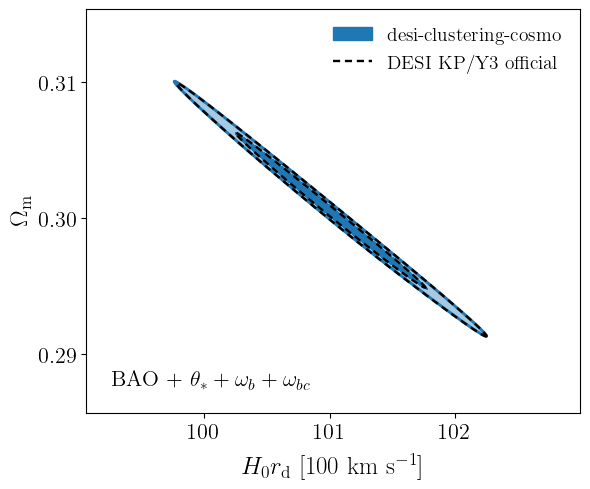

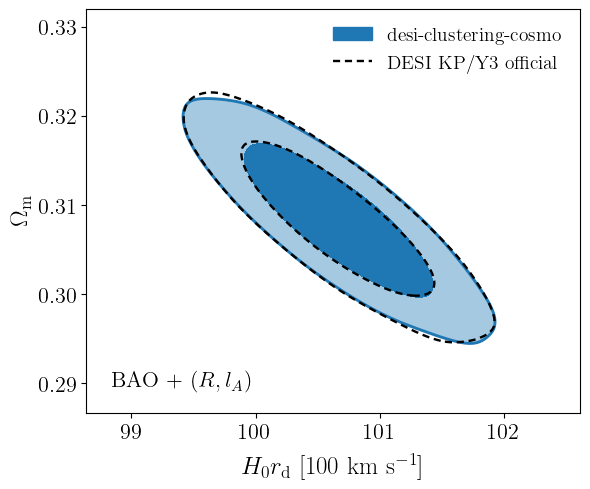

In [12]:
# Compact grid of the simple cases in the shared BAO plane.
for case in CASES:
    plot_pipeline_vs_official(case, "hrdrag", "omm", save=True)


## Interpreting the two visibly imperfect overlays

Two panels deserve extra context:

- **BAO + DESY5-Dovekie** is intentionally shown against Cristhian's archived official BAO+SN chain at `desi_dr2_updated/base/DESI_BAO_DESY5-Dovekie`. The sibling directory `desi_dr2_updated/base/DESY5-Dovekie` is SN-only and should not be used for the `bao-sn-desdovekie` comparison. The `desi-clustering-cosmo` run uses the standard v1p2 DR2 BAO data product (`cosmo.cobaya.external_likelihoods.bao.desi_dr2.desi_dr2_bao_all` with `bao_v1p2/bao/cobaya_data`), while the archived official BAO+SN Dovekie chain uses `bao.desi_dr2_updated.desi_bao_all` with `bao_data/desi_bao_dr2_updated`. The SN likelihood is the same (`sn.desdovekie`) and both chains are converged, so this panel shows the current BAO-product offset to diagnose with Cristhian.
  - convergence: `desi-clustering-cosmo Rminus1_cl=0.0187`, archived official `Rminus1_cl=0.0198`;
  - parameter shifts: `H0 r_d/100` differs by `0.21` joint sigma, `Omega_m` by `0.15` joint sigma.

- **BAO + theta_star** is effectively an apples-to-apples check for the likelihood definition. The official chain available here is from the v1p1 root, but the combined BAO mean/cov files match the v1p2 files used by `desi-clustering-cosmo`, and the compressed-CMB mean/cov are identical. Both chains are converged; the residual shift is only `~0.03` joint sigma in the plotted parameters, so the visual difference is consistent with finite-chain/KDE-contour noise rather than a physics or likelihood mismatch.


## BAO-only and SN-only Dovekie diagnostics

To isolate the source of the BAO+DESY5-Dovekie offset, this section compares the pieces separately:

1. **BAO-only:** `desi-clustering-cosmo` standard v1p2 BAO (`desi-bao-all`) against Cristhian's archived updated-BAO-only chain (`desi_dr2_updated/base/DESI_BAO`). This directly measures the standard-v1p2-vs-`bao.desi_dr2_updated` BAO-product shift.
2. **SN-only:** `desi-clustering-cosmo` `sn.desdovekie` only (`desdovekie`) against Cristhian's archived SN-only chain (`desi_dr2_updated/base/DESY5-Dovekie`). This checks whether the Dovekie SN likelihood itself agrees when BAO is removed.

These diagnostics are not replacements for the main BAO+SN validation panel; they just identify whether the residual comes from BAO, SN, or both.


In [13]:
DIAGNOSTIC_CHAINS = OrderedDict({
    "bao-only-standard-vs-updated": {
        "label": "BAO only: standard v1p2 vs updated BAO",
        "params": ["hrdrag", "omm"],
        "plot_type": "2d",
        "chains": OrderedDict({
            "desi-clustering-cosmo standard v1p2 BAO": DESI_CLUSTERING_ROOT / "desi-bao-all",
            "Cristhian archived updated BAO": OFFICIAL_DR2_UPDATED_ROOT / "DESI_BAO",
        }),
    },
    "sn-only-desdovekie": {
        "label": "SN only: DESY5-Dovekie",
        "params": ["omm"],
        "plot_type": "1d",
        "chains": OrderedDict({
            "desi-clustering-cosmo sn.desdovekie": DESI_CLUSTERING_ROOT / "desdovekie",
            "Cristhian archived sn.desdovekie": OFFICIAL_DR2_UPDATED_ROOT / "DESY5-Dovekie",
        }),
    },
})


def load_diagnostic_samples():
    samples = OrderedDict()
    rows = []
    for diag_key, cfg in DIAGNOSTIC_CHAINS.items():
        samples[diag_key] = OrderedDict()
        for label, chain_dir in cfg["chains"].items():
            exists = chain_exists(chain_dir)
            rows.append({
                "diagnostic": diag_key,
                "label": cfg["label"],
                "source": label,
                "chain_dir": str(chain_dir),
                "exists": exists,
            })
            if exists:
                samples[diag_key][label] = load_chain(chain_dir, label=label, ignore_rows=0.3)
    return samples, pd.DataFrame(rows)


def progress_for_dir(chain_dir):
    info = read_progress(chain_dir)
    return {k: info.get(k, np.nan) for k in ["N", "acceptance_rate", "Rminus1", "Rminus1_cl", "timestamp"]}


def diagnostic_shift_table(diagnostic_samples):
    rows = []
    for diag_key, cfg in DIAGNOSTIC_CHAINS.items():
        loaded = diagnostic_samples.get(diag_key, OrderedDict())
        labels = list(loaded)
        if len(labels) != 2:
            continue
        ref0, ref1 = labels
        s0, s1 = loaded[ref0], loaded[ref1]
        for par in ["hrdrag", "omm", "omegam", "rdrag", "H0", "chi2", "chi2__BAO", "chi2__SN"]:
            if has_param(s0, par) and has_param(s1, par):
                m0, e0 = s0.mean(par), s0.std(par)
                m1, e1 = s1.mean(par), s1.std(par)
                rows.append({
                    "diagnostic": diag_key,
                    "param": par,
                    labels[0] + " mean": m0,
                    labels[0] + " std": e0,
                    labels[1] + " mean": m1,
                    labels[1] + " std": e1,
                    "delta": m0 - m1,
                    "joint_sigma_shift": (m0 - m1) / np.sqrt(e0**2 + e1**2),
                })
    return pd.DataFrame(rows)


def plot_getdist_1d(samples_by_label, par="omm", title=None, filename=None):
    roots = list(samples_by_label.values())
    labels = list(samples_by_label)
    colors = ["C0", "k", "C1", "C2"]
    linestyles = ["-", "--", ":", "-."]
    g = plots.get_single_plotter(width_inch=getdist_2D_width_inch, ratio=getdist_2D_ratio, scaling=True)
    if style is not None:
        g.settings = style.settings
    g.plot_1d(roots, par, colors=colors[:len(roots)], ls=linestyles[:len(roots)])
    g.add_legend(labels, legend_loc="upper right", fontsize=9)
    ax = g.get_axes()
    if title:
        ax.text(0.03, 0.96, title, transform=ax.transAxes, ha="left", va="top", fontsize=12)
    stat_lines = []
    for label, sample in samples_by_label.items():
        stat_lines.append(f"{label}: {sample.mean(par):.5f} ± {sample.std(par):.5f}")
    ax.text(
        0.03,
        0.84 if title else 0.96,
        "\n".join(stat_lines),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 3},
    )
    if par in {"omm", "omegam"}:
        ax.set_xlabel(r"$\Omega_\mathrm{m}$")
    if filename:
        plt.savefig(OUTDIR / filename, bbox_inches="tight")
    return g


def plot_diagnostic_2d(samples_by_label, x="hrdrag", y="omm", title=None, filename=None):
    roots = list(samples_by_label.values())
    labels = list(samples_by_label)
    g = plots.get_single_plotter(width_inch=getdist_2D_width_inch, ratio=getdist_2D_ratio, scaling=True)
    if style is not None:
        g.settings = style.settings
    g.plot_2d(roots, [x, y], filled=[True, False], colors=["C0", "k"], ls=["-", "--"])
    g.add_legend(labels, legend_loc="upper right")
    if title:
        g.add_text(title, 0.05, 0.08, fontsize=14)
    ax = g.get_axes()
    if x == "hrdrag": ax.set_xlabel(r"$H_0 r_\mathrm{d}$ [100 $\mathrm{km}$ $\mathrm{s}^{-1}$]")
    if y in {"omm", "omegam"}: ax.set_ylabel(r"$\Omega_\mathrm{m}$")
    if filename:
        plt.savefig(OUTDIR / filename, bbox_inches="tight")
    return g


diagnostic_samples, diagnostic_availability = load_diagnostic_samples()
diagnostic_availability


,diagnostic,label,source,chain_dir,exists
0,bao-only-standard-vs-updated,BAO only: standard v1p2 vs updated BAO,desi-clustering-cosmo standard v1p2 BAO,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True
1,bao-only-standard-vs-updated,BAO only: standard v1p2 vs updated BAO,Cristhian archived updated BAO,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True
2,sn-only-desdovekie,SN only: DESY5-Dovekie,desi-clustering-cosmo sn.desdovekie,/pscratch/sd/u/uendert/desi-clustering-cosmo-d...,True
3,sn-only-desdovekie,SN only: DESY5-Dovekie,Cristhian archived sn.desdovekie,/global/cfs/cdirs/desicollab/science/cpe/y3_ba...,True


In [14]:
diagnostic_progress_rows = []
for diag_key, cfg in DIAGNOSTIC_CHAINS.items():
    for label, chain_dir in cfg["chains"].items():
        diagnostic_progress_rows.append({
            "diagnostic": diag_key,
            "source": label,
            **progress_for_dir(chain_dir),
        })
diagnostic_progress = pd.DataFrame(diagnostic_progress_rows)
diagnostic_progress


,diagnostic,source,N,acceptance_rate,Rminus1,Rminus1_cl,timestamp
0,bao-only-standard-vs-updated,desi-clustering-cosmo standard v1p2 BAO,50172.0,0.756363,0.001020,0.019861,2026-05-28T14:16:42.693449
1,bao-only-standard-vs-updated,Cristhian archived updated BAO,52086.0,0.758685,0.000260,0.019346,2026-04-25T02:37:32.799755
2,sn-only-desdovekie,desi-clustering-cosmo sn.desdovekie,10857.0,0.491222,0.000796,0.015951,2026-06-30T02:49:42.599454
3,sn-only-desdovekie,Cristhian archived sn.desdovekie,5992.0,0.503588,0.000470,0.017468,2026-04-28T17:51:31.527148


In [15]:
diagnostic_shifts = diagnostic_shift_table(diagnostic_samples)
diagnostic_shifts


,diagnostic,param,desi-clustering-cosmo standard v1p2 BAO mean,desi-clustering-cosmo standard v1p2 BAO std,Cristhian archived updated BAO mean,Cristhian archived updated BAO std,delta,joint_sigma_shift,desi-clustering-cosmo sn.desdovekie mean,desi-clustering-cosmo sn.desdovekie std,Cristhian archived sn.desdovekie mean,Cristhian archived sn.desdovekie std
0,bao-only-standard-vs-updated,hrdrag,101.521945,0.738297,101.195034,0.668747,3.269109e-01,0.328176,NaN,NaN,NaN,NaN
1,bao-only-standard-vs-updated,omm,0.297641,0.008619,0.301127,0.007616,-3.485969e-03,-0.303073,NaN,NaN,NaN,NaN
2,bao-only-standard-vs-updated,omegam,0.297641,0.008619,0.301128,0.007616,-3.487457e-03,-0.303202,NaN,NaN,NaN,NaN
3,bao-only-standard-vs-updated,rdrag,150.715476,1.096046,150.230157,0.992796,4.853190e-01,0.328176,NaN,NaN,NaN,NaN
4,bao-only-standard-vs-updated,H0,67.360000,0.000002,67.360000,0.000002,1.972323e-08,0.006101,NaN,NaN,NaN,NaN
5,bao-only-standard-vs-updated,chi2,12.295668,2.007588,14.883320,2.014468,-2.587651e+00,-0.909855,NaN,NaN,NaN,NaN
6,bao-only-standard-vs-updated,chi2__BAO,12.295668,2.007588,14.883320,2.014468,-2.587651e+00,-0.909855,NaN,NaN,NaN,NaN
7,sn-only-desdovekie,omm,NaN,NaN,NaN,NaN,5.686278e-04,0.026404,0.331227,0.015484,0.330658,0.014968
8,sn-only-desdovekie,omegam,NaN,NaN,NaN,NaN,5.671401e-04,0.026335,0.331227,0.015484,0.330660,0.014968
9,sn-only-desdovekie,chi2,NaN,NaN,NaN,NaN,6.782746e-02,0.034773,1632.448387,1.419720,1632.380560,1.337623


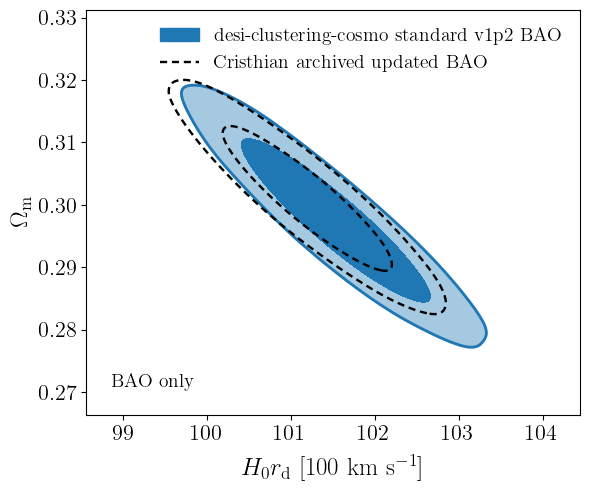

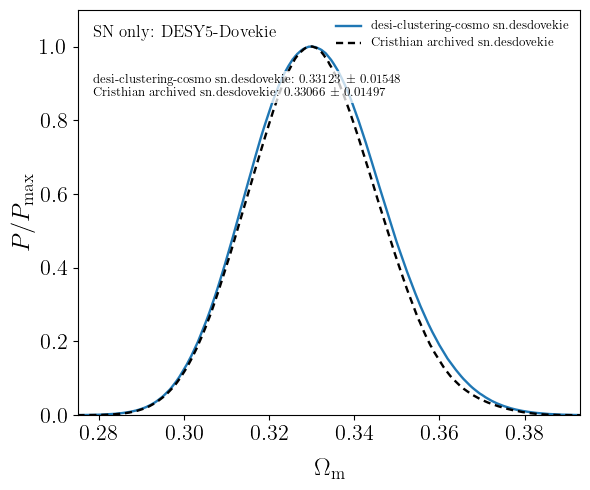

In [16]:
plot_diagnostic_2d(
    diagnostic_samples["bao-only-standard-vs-updated"],
    x="hrdrag",
    y="omm",
    title="BAO only",
    filename="diagnostic_bao_only_standard_v1p2_vs_dr2_updated_hrdrag_omm.pdf",
)
plot_getdist_1d(
    diagnostic_samples["sn-only-desdovekie"],
    par="omm",
    title="SN only: DESY5-Dovekie",
    filename="diagnostic_sn_only_desdovekie_omm.pdf",
)


## Calibrated-distance apples-to-apples comparisons

For BBN/compressed-CMB cases, `H0` is available or derived from `hrdrag` and `rdrag`. These plots are closer to the calibrated-distance checks in the KP notebook.

This section uses `bao-bbn-fixed-nnu` for the BBN validation because it is the apples-to-apples fixed-`N_eff` match to the DESI KP/Y3 official `base` BBN chain. The varied-`N_eff` `bao-bbn` stress test is intentionally excluded from this validation notebook.


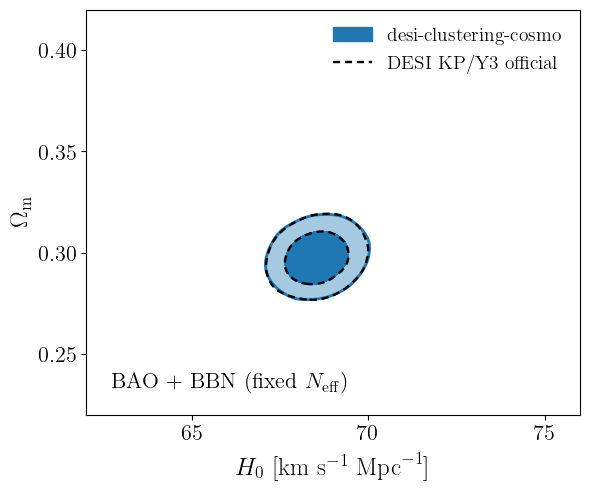

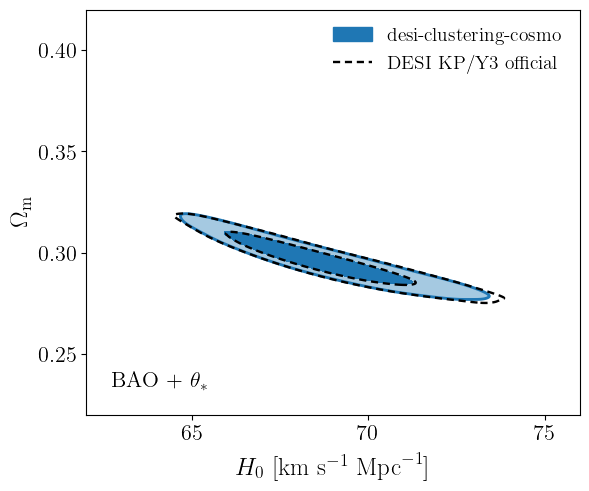

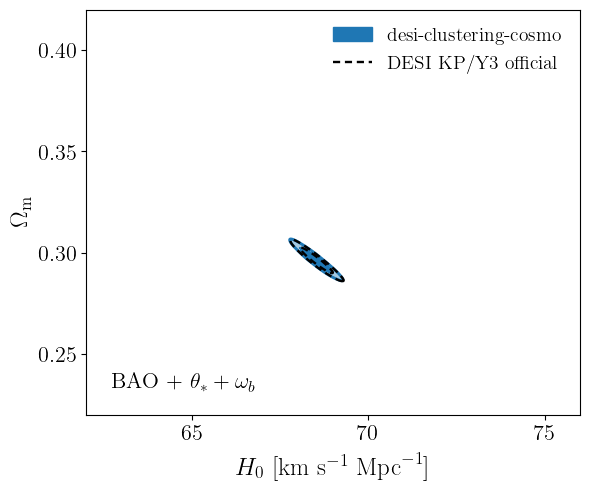

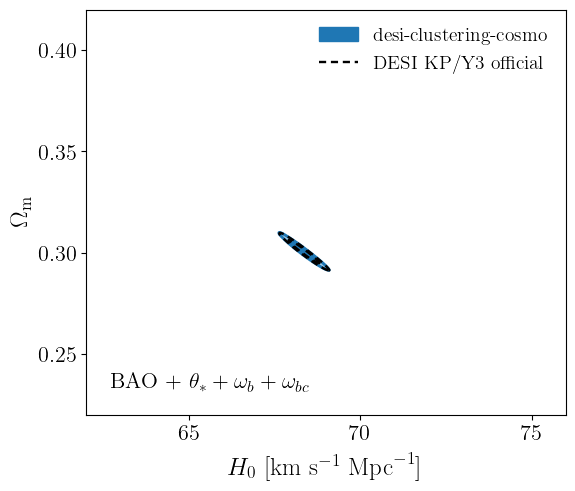

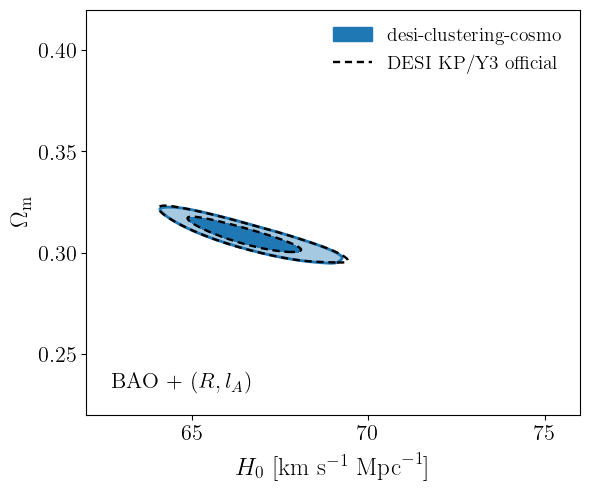

In [17]:
calibrated_cases = ["bao-bbn-fixed-nnu", "bao-cmb-compressed-theta", "bao-cmb-compressed-theta-ombh2", "bao-cmb-compressed-theta-ombh2-ombch2", "bao-cmb-compressed-r-la"]
for case in calibrated_cases:
    plot_pipeline_vs_official(case, "H0", "omm", limits={"xlim": (62, 76), "ylim": (0.22, 0.42)}, save=True)


## Overlay of simple `desi-clustering-cosmo` chains

A quick view of how the simple additions calibrate/rotate the BAO-only degeneracy, using only the `desi-clustering-cosmo` chains from `uendert-cosmo-dev-mcmc-v2`.


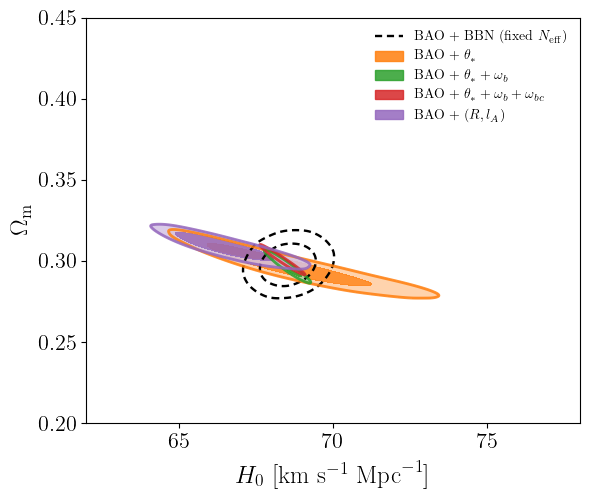

In [18]:
# Only include cases where H0 is genuinely constrained/sampled.
# BAO-only and BAO+SN background runs have effectively fixed H0, so they collapse to vertical lines.
plot_cases = [case for case in calibrated_cases if case in pipeline_samples]
roots = [pipeline_samples[case] for case in plot_cases]
labels = [CASES[case]["label"] for case in plot_cases]
colors = ["k", "C1", "C2", "C3", "C4", "C5", "C6"][:len(roots)]
filled = [False] + [True] * (len(roots) - 1)
g = plots.get_single_plotter(width_inch=getdist_2D_width_inch, ratio=getdist_2D_ratio, scaling=True)
if style is not None:
    g.settings = style.settings
g.plot_2d(roots, ["H0", "omm"], filled=filled, colors=colors, ls=["--"] + ["-"] * (len(roots) - 1))
g.add_legend(labels, legend_loc="upper right", legend_ncol=1, fontsize=10)
ax = g.get_axes()
ax.set_xlabel(r"$H_0$ [$\mathrm{km}$ $\mathrm{s}^{-1}$ $\mathrm{Mpc}^{-1}$]")
ax.set_ylabel(r"$\Omega_\mathrm{m}$")
ax.set_xlim(62, 78)
ax.set_ylim(0.20, 0.45)
plt.savefig(OUTDIR / "desi_clustering_simple_cases_H0_omm.pdf", bbox_inches="tight")


## Notes / next checks

- This notebook is intended as a validation that the new `desi-clustering-cosmo` simple/background Cobaya pipeline reproduces DESI KP/Y3 official-pipeline results.
- If a `desi-clustering-cosmo`/official shift is large, first confirm the likelihood definitions and data products match exactly. `desi-clustering-cosmo` uses the DR2 BAO files registered in `cosmo.cobaya.mapping_likelihoods`, while the KP/Y3 helper notebook can point to different combined-tracer products.
- The Dovekie comparison currently uses Cristhian's archived official BAO+SN chain `desi_dr2_updated/base/DESI_BAO_DESY5-Dovekie`. Do not replace it with `desi_dr2_updated/base/DESY5-Dovekie`, which is SN-only. The remaining question is whether there is an archived standard-v1p2-BAO + `sn.desdovekie` chain, or where the exact `bao.desi_dr2_updated` data package lives.
- `bao-bbn-fixed-nnu` is the strict apples-to-apples fixed-`N_eff` comparison to the DESI KP/Y3 official base BBN chain. The varied-`N_eff` `bao-bbn` stress test is intentionally not plotted in this validation notebook.
- The theta-only and `R,l_A` official comparisons are v1p1 fallbacks.
- CMB-SPA chains exist in the same `desi-clustering-cosmo` root, but they are intentionally not part of this simple-case validation notebook; the goal here is to isolate the remaining small background-distance differences before moving to full-CMB combinations.
